In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    log_loss, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import warnings
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform
import time
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('../encoded_fourth_downs.csv.gz', low_memory=False, compression='gzip')


In [3]:
# Map play types to the three decision categories
play_type_map = {
    'run': 'go',
    'pass': 'go',
    'punt': 'punt',
    'field_goal': 'field_goal'
#    'hard_count': 'hard_count' # removing hard count because it pollutes the other buckets. totally different interpretation
}

# Identify play_type column — adjust name if yours differs
# The encoded version splits into dummies; reconstruct if needed
play_type_cols = [c for c in df.columns if c.startswith('play_type_') 
                  and c in ['play_type_pass', 'play_type_run', 'play_type_punt']]
# append 'is_hard_count' if it exists
if 'is_hard_count' in df.columns:
    play_type_cols.append('is_hard_count')

# If play_type is already a raw string column, use it directly
if 'play_type' in df.columns:
    df['decision'] = df['play_type'].map(play_type_map)
else:
    # Reconstruct from dummies
    def get_decision(row):
    #    if row.get('is_hard_count', 0) == 1:
    #        return 'hard_count'
        if row.get('play_type_pass', 0) == 1 or row.get('play_type_run', 0) == 1:
            return 'go'
        elif row.get('play_type_punt', 0) == 1:
            return 'punt'
        elif row.get('field_goal_attempt', 0) == 1:
            return 'field_goal'
        else:
            return np.nan
    df['decision'] = df.apply(get_decision, axis=1)

# Drop rows without a clear decision or missing EPA
df_clean = df.dropna(subset=['decision', 'epa']).copy()
df_clean = df_clean[df_clean['decision'].isin(['go', 'punt', 'field_goal'])]

# Exclude hard counts (no real play ran)
#if 'is_hard_count' in df_clean.columns:
#    df_clean = df_clean[df_clean['is_hard_count'] != 1]

print(f'Usable 4th down plays: {len(df_clean):,}')
print(df_clean['decision'].value_counts())

Usable 4th down plays: 34,897
decision
punt          19488
field_goal     8571
go             6838
Name: count, dtype: int64


In [4]:
# Bin continuous situational variables into buckets
df_clean['ydstogo_bin'] = pd.cut(df_clean['ydstogo'], bins=[0, 1, 3, 6, 10, 99], 
                                  labels=['1', '2-3', '4-6', '7-10', '10+'])
df_clean['yardline_bin'] = pd.cut(df_clean['yardline_100'], bins=[0, 20, 40, 60, 80, 100],
                                   labels=['opp_red_zone', 'opp_40', 'midfield', 'own_40', 'own_end'])
df_clean['score_diff_bin'] = pd.cut(df_clean['score_differential'], 
                                     bins=[-100, -14, -7, -3, 3, 7, 14, 100],
                                     labels=['down_14+', 'down_8-14', 'down_1-7', 
                                             'close', 'up_1-7', 'up_8-14', 'up_14+'])

# Era indicator for kickoff rule change
df_clean['kickoff_era'] = df_clean['season'].apply(
    lambda s: 'dynamic' if s >= 2023 else 'traditional'
)

In [5]:
# Group key
group_cols = ['ydstogo_bin', 'yardline_bin', 'score_diff_bin', 'kickoff_era']

# Mean EPA per decision type within each situational bucket
epa_by_situation = (
    df_clean
    .groupby(group_cols + ['decision'])['epa']
    .mean()
    .reset_index()
    .rename(columns={'epa': 'mean_epa'})
)

# Pivot so each row is a situation with one column per decision type
epa_pivot = epa_by_situation.pivot_table(
    index=group_cols, columns='decision', values='mean_epa'
).reset_index()
epa_pivot.columns.name = None

# Fill missing decision types with NaN (bucket had no plays of that type)
for col in ['go', 'punt', 'field_goal']:
    if col not in epa_pivot.columns:
        epa_pivot[col] = np.nan

# Optimal decision = whichever decision has highest mean EPA in that bucket
epa_pivot['optimal_decision'] = epa_pivot[['go', 'punt', 'field_goal']].idxmax(axis=1)

print(f'Unique situational buckets: {len(epa_pivot):,}')
print(epa_pivot['optimal_decision'].value_counts())
epa_pivot.head(20)

Unique situational buckets: 350
optimal_decision
go            134
punt          113
field_goal    103
Name: count, dtype: int64


,ydstogo_bin,yardline_bin,score_diff_bin,kickoff_era,field_goal,go,punt,optimal_decision
0,1,opp_red_zone,down_14+,dynamic,NaN,0.541353,NaN,go
1,1,opp_red_zone,down_14+,traditional,0.218074,-0.483288,NaN,field_goal
2,1,opp_red_zone,down_8-14,dynamic,0.104501,0.692004,NaN,go
3,1,opp_red_zone,down_8-14,traditional,-0.045676,-0.343601,NaN,field_goal
4,1,opp_red_zone,down_1-7,dynamic,0.197110,-0.215262,NaN,field_goal
5,1,opp_red_zone,down_1-7,traditional,0.125031,-0.708669,NaN,field_goal
6,1,opp_red_zone,close,dynamic,0.025380,-0.392689,NaN,field_goal
7,1,opp_red_zone,close,traditional,-0.187967,-0.294438,NaN,field_goal
8,1,opp_red_zone,up_1-7,dynamic,-0.801081,-0.215653,NaN,go
9,1,opp_red_zone,up_1-7,traditional,0.161594,-0.793150,NaN,field_goal


In [6]:
# Merge optimal_decision back onto the play-level data
df_model = df_clean.merge(epa_pivot[group_cols + ['optimal_decision']], 
                           on=group_cols, how='left')

# Drop rows where optimal_decision couldn't be determined (sparse buckets)
df_model = df_model.dropna(subset=['optimal_decision'])

print(f'Model-ready rows: {len(df_model):,}')
print(df_model['optimal_decision'].value_counts())

Model-ready rows: 34,897
optimal_decision
go            13121
punt          11266
field_goal    10510
Name: count, dtype: int64


In [7]:
# Core situational features
pre_snap_features = [
    'yardline_100',        # field position (yards from end zone)
    'ydstogo',             # yards needed for first down
    'score_differential',  # score diff (positive = winning)
    'game_seconds_remaining',
    'half_seconds_remaining',
    'qtr',
    'posteam_timeouts_remaining',
    'defteam_timeouts_remaining',
    'goal_to_go',
    'shotgun',
    'no_huddle',
    'home_is_posteam',     # home/away context
]

# EPA-based pregame context (these are pre-game, not post-play)
pregame_epa_features = [
    'no_score_prob', 'opp_fg_prob', 'opp_td_prob',
    'fg_prob', 'td_prob',   # pre-snap win probability components
]

# Kickoff era indicator
era_features = ['kickoff_era']

# Playcaller dummies (coaching tendency)
playcaller_cols = [c for c in df_model.columns if c.startswith('playcaller_')]

# Season fixed effects
df_model['season_fixed'] = df_model['season'].astype(str)

all_features = pre_snap_features + pregame_epa_features + playcaller_cols

# Encode era as binary
df_model['is_dynamic_era'] = (df_model['kickoff_era'] == 'dynamic').astype(int)
all_features.append('is_dynamic_era')

# Season dummies
season_dummies = pd.get_dummies(df_model['season'], prefix='season', drop_first=True)
df_model = pd.concat([df_model, season_dummies], axis=1)
all_features += list(season_dummies.columns)

# Keep only features actually present in the dataframe
all_features = [f for f in all_features if f in df_model.columns]

print(f'Total features: {len(all_features)}')
print(all_features)

Total features: 113
['yardline_100', 'ydstogo', 'score_differential', 'game_seconds_remaining', 'half_seconds_remaining', 'qtr', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'goal_to_go', 'shotgun', 'no_huddle', 'home_is_posteam', 'no_score_prob', 'opp_fg_prob', 'opp_td_prob', 'fg_prob', 'td_prob', 'playcaller_Alex Van Pelt', 'playcaller_Andy Reid', 'playcaller_Anthony Lynn', 'playcaller_Arthur Smith', 'playcaller_Ben Johnson', 'playcaller_Ben McAdoo', 'playcaller_Bill Lazor', 'playcaller_Bill Musgrave', "playcaller_Bill O'Brien", 'playcaller_Bo Hardegree', 'playcaller_Bobby Slowik', 'playcaller_Brian Callahan', 'playcaller_Brian Daboll', 'playcaller_Brian Johnson', 'playcaller_Brian Schottenheimer', 'playcaller_Byron Leftwich', "playcaller_Chad O'Shea", 'playcaller_Chan Gailey', 'playcaller_Darrell Bevell', 'playcaller_Dave Canales', 'playcaller_Dave Ragone', 'playcaller_Dirk Koetter', 'playcaller_Doug Pederson', 'playcaller_Dowell Loggains', 'playcaller_Drew Petzing', 

In [14]:
# Build X and y, drop rows with any NaN in features
X = df_model[all_features].copy()
y = df_model['optimal_decision'].copy()

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Drop rows with missing feature values
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

# Encode target labels to integers
le = LabelEncoder()
y = pd.Series(le.fit_transform(y), index=y.index)

print(f'Final dataset: {len(X):,} plays')
print(f'Class distribution:\n{y.value_counts()}')

Final dataset: 34,897 plays
Class distribution:
1    13121
2    11266
0    10510
Name: count, dtype: int64


In [15]:
TEST_SEASON = 2024

season_col = df_model.loc[mask, 'season']

train_idx = season_col[season_col < TEST_SEASON].index
test_idx  = season_col[season_col == TEST_SEASON].index

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f'Train: {len(X_train):,} plays  |  Test: {len(X_test):,} plays')
print(f'Train seasons: {sorted(season_col[train_idx].unique())}')
print(f'Test season:   {sorted(season_col[test_idx].unique())}')

Train: 26,351 plays  |  Test: 4,556 plays
Train seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Test season:   [np.int64(2024)]


In [10]:
## Load prescriptive model params from json file
import json
with open('best_xgb_params.json', 'r') as f:
    xgb_best_params = json.load(f)

# initialize prescriptive model with best params
prescriptive_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    **xgb_best_params
)

In [11]:
## Load predictive model params from json file
with open('best_predictive_xgb_params.json', 'r') as f:
    xgb_predictive_best_params = json.load(f)

predictive_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    **xgb_predictive_best_params
)

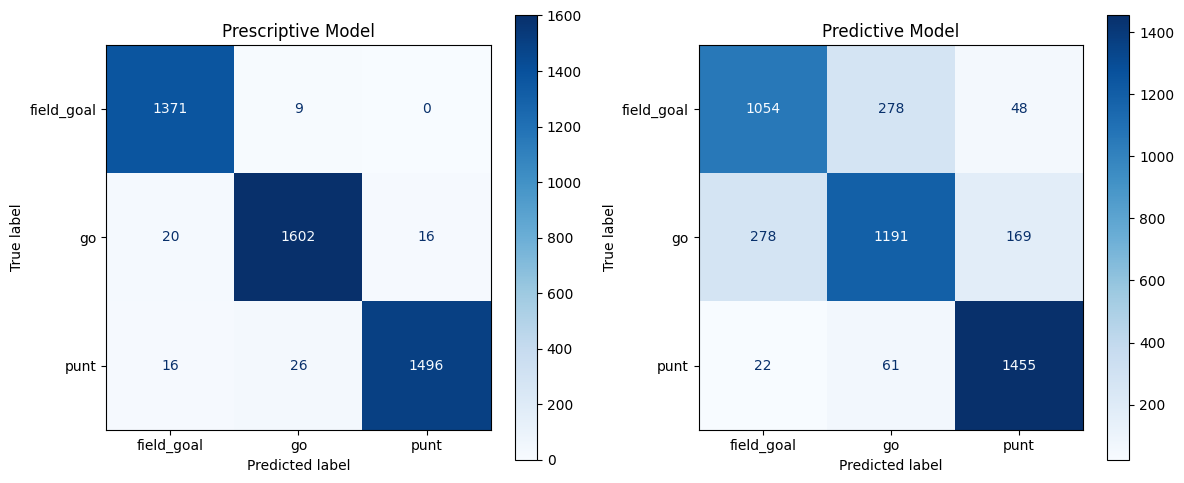

In [16]:
## Run predictions on both models
# Fit prescriptive model on training data

prescriptive_model.fit(X_train, y_train)
# Fit predictive model on training data
predictive_model.fit(X_train, y_train)

prescriptive_preds = prescriptive_model.predict(X_test)
predictive_preds = predictive_model.predict(X_test)

## Compare confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes = prescriptive_model.classes_
for ax, preds, title in zip(
    axes,
    [prescriptive_preds, predictive_preds],
    ['Prescriptive Model', 'Predictive Model']
):
    cm = confusion_matrix(y_test, preds, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [ ]:
## 